In [728]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import StandardScaler
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
from tqdm import tqdm
import os
os.getcwd()

'c:\\Users\\Bruno\\Desktop\\Personal-projects-1\\Proyectos de Astronomía\\Laboratorio 4'

In [729]:
df = pd.read_csv("dataset_100pc(in).csv").dropna(subset='pmra') # full gaia sample for one cluster
df = df.dropna(subset=['ra', 'dec', 'pmra','pmdec','parallax','bp_rp','phot_g_mean_mag'])
df.info(), df.columns

<class 'pandas.core.frame.DataFrame'>
Index: 497992 entries, 0 to 574530
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 497992 non-null  int64  
 1   source_id                  497992 non-null  int64  
 2   ra                         497992 non-null  float64
 3   dec                        497992 non-null  float64
 4   parallax                   497992 non-null  float64
 5   pmra                       497992 non-null  float64
 6   pmdec                      497992 non-null  float64
 7   ruwe                       497992 non-null  float64
 8   phot_g_mean_mag            497992 non-null  float64
 9   bp_rp                      497992 non-null  float64
 10  radial_velocity            168209 non-null  float64
 11  ra_error                   497992 non-null  float64
 12  dec_error                  497992 non-null  float64
 13  pmra_error                 497992 

(None,
 Index(['Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
        'ruwe', 'phot_g_mean_mag', 'bp_rp', 'radial_velocity', 'ra_error',
        'dec_error', 'pmra_error', 'pmdec_error', 'parallax_error',
        'visibility_periods_used', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
        'nu_eff_used_in_astrometry', 'pseudocolour', 'ecl_lat',
        'astrometric_params_solved', 'zp', 'fidelity_v2'],
       dtype='object'))

In [730]:
df["dist_pc"] = 1000 / df["parallax"]
df["parallax_over_error"] = df["parallax_error"]/df["parallax"]
df46 = df[(df["dist_pc"] > 26) & (df["dist_pc"] < 66)]
df46 = df46[(df46["ra"]>51) & (df46["ra"] < 81)]
df46 = df46[(df46["dec"]>1) & (df46["dec"] < 31)]
print(len(df46["ra"]))
df46 = df46[(df46["parallax_over_error"] <= 0.1)]
pmra46 = df46["pmra"].values
pmdec46 = df46["pmdec"].values
print(len(df46["ra"]))

2381
2367


In [ ]:
clustering_on = ['pmra','pmdec','dist_pc']
data = df46[clustering_on]
features = data
data = RobustScaler().fit_transform(data)

In [ ]:
hd = HDBSCAN(min_cluster_size=45, min_samples=5, metric='euclidean').fit(data)

from sklearn.metrics import silhouette_samples, silhouette_score

In [733]:
labels = hd.labels_ 
df46['label_hb'] = labels

for i in list(set(labels)):
    print('{} {}'.format(i,len(df46[(df46['label_hb'] == i)])))
    
unique_labels = np.unique(labels)

# mapa de colores
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

# diccionario label -> color
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

0 46
1 393
2 49
-1 1879


In [734]:
# encontrar el cluster más grande (ignorando ruido)
df46["label_hb"] = df46["label_hb"].replace(1, 2)
cluster_sizes = df46[df46['label_hb'] != -1]['label_hb'].value_counts()
main_cluster = cluster_sizes.idxmax()
pmra_c = df46[df46['label_hb']==main_cluster]['pmra']
pmdec_c = df46[df46['label_hb']==main_cluster]['pmdec']
pmra_center = pmra_c.mean()
pmdec_center = pmdec_c.mean()

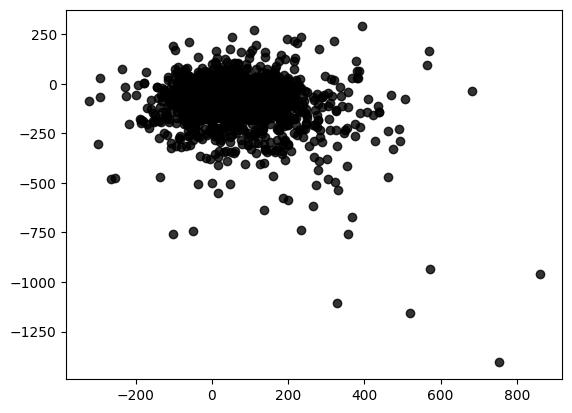

In [735]:
#VPD
plt.scatter(df46['pmra'], df46['pmdec'],c='k',alpha=0.8)
plt.show()

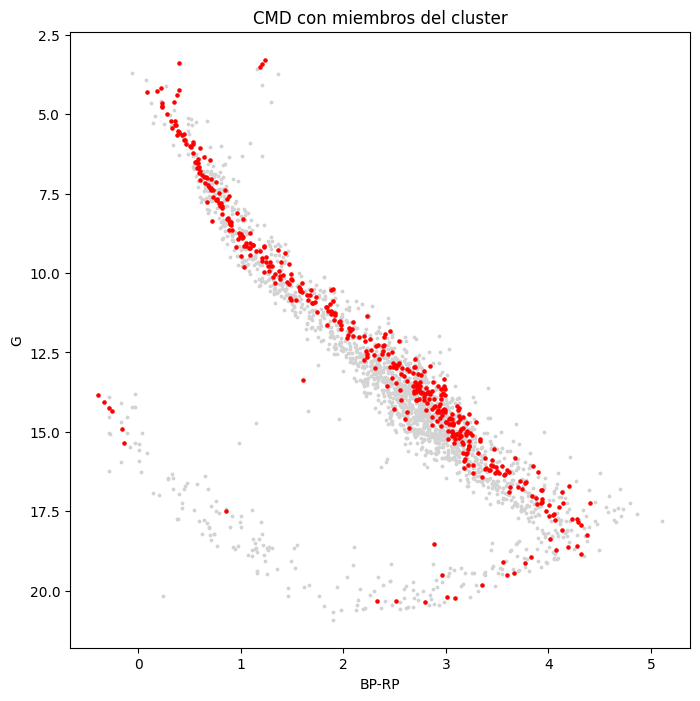

In [736]:
plt.figure(figsize=(8,8))
members = df46[df46['label_hb']==main_cluster]
plt.scatter(df46['bp_rp'],df46['phot_g_mean_mag'],c='lightgray',s=3)
plt.scatter(members['bp_rp'],members['phot_g_mean_mag'],c='red',s=5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP")
plt.ylabel("G")
plt.title("CMD con miembros del cluster")
plt.show()

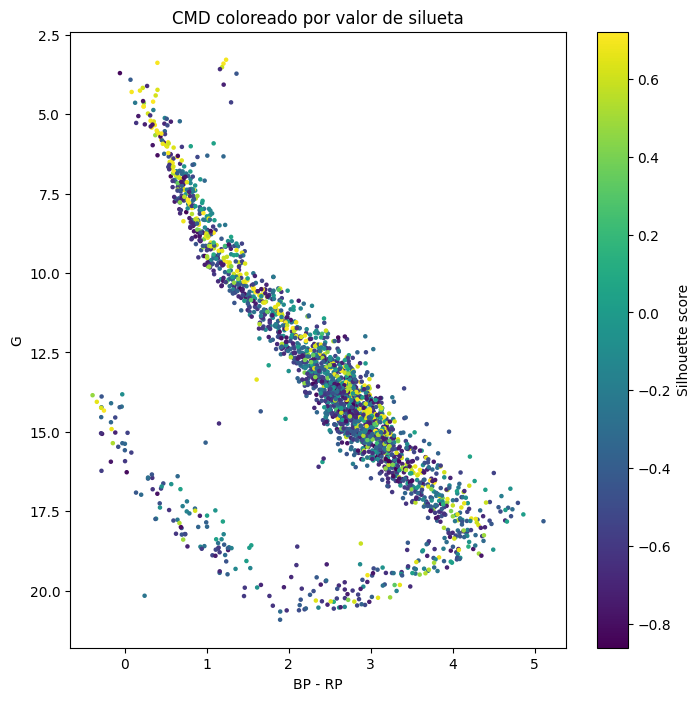

In [737]:
x = silhouette_samples(data, labels)
sil = x

df46['silhouette'] = sil

plt.figure(figsize=(8,8))
sc = plt.scatter(df46['bp_rp'],df46['phot_g_mean_mag'],c=df46['silhouette'],cmap='viridis',s=5)
plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("CMD coloreado por valor de silueta")
plt.colorbar(sc,label="Silhouette score")
plt.show()

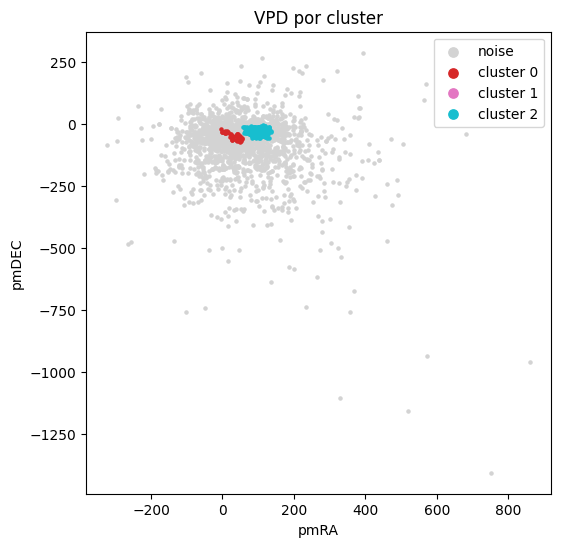

In [738]:
plt.figure(figsize=(6,6))

for lab in unique_labels:

    cond = df46['label_hb'] == lab
    
    if lab == -1:
        color = 'lightgray'
        label = 'noise'
    else:
        color = color_map[lab]
        label = f'cluster {lab}'
    
    plt.scatter(df46['pmra'][cond],df46['pmdec'][cond],s=5,color=color,label=label)

plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.title("VPD por cluster")
plt.legend(markerscale=3)
plt.show()

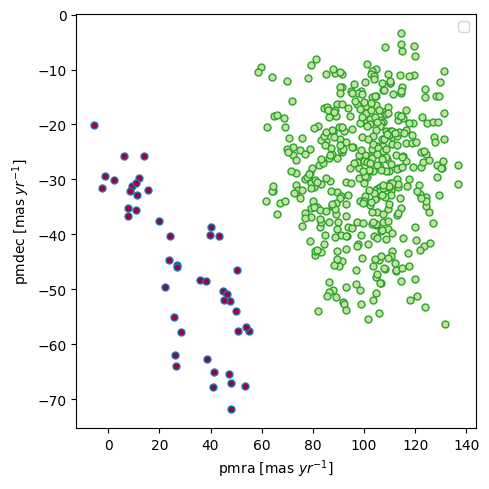

In [739]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (df46['label_hb'] == i)
        plt.plot(df46['pmra'][condition], df46['pmdec'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None',markersize = 5, alpha = 1)
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.legend()
plt.show() 

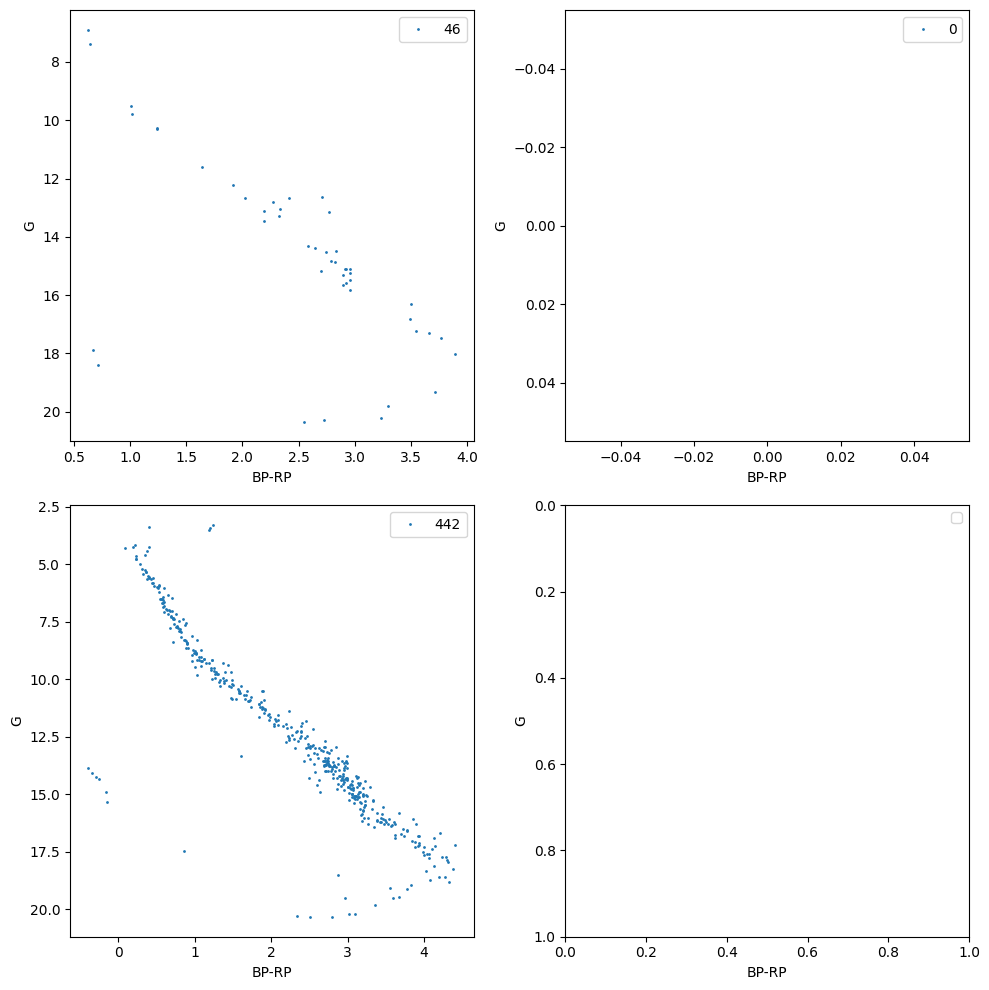

In [740]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))

for i, j, ax in zip(list(unique_labels), colors, axes.flat):
    if i != -1:
        condition = (df46['label_hb'] == i)
        ax.plot(df46['phot_bp_mean_mag'][condition] - df46['phot_rp_mean_mag'][condition], df46['phot_g_mean_mag'][condition], 
         markerfacecolor = tuple(j), marker='o', linestyle='None', markersize=1, label=f'{len(df46[condition])}')
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend()

fig.tight_layout()
plt.show() 

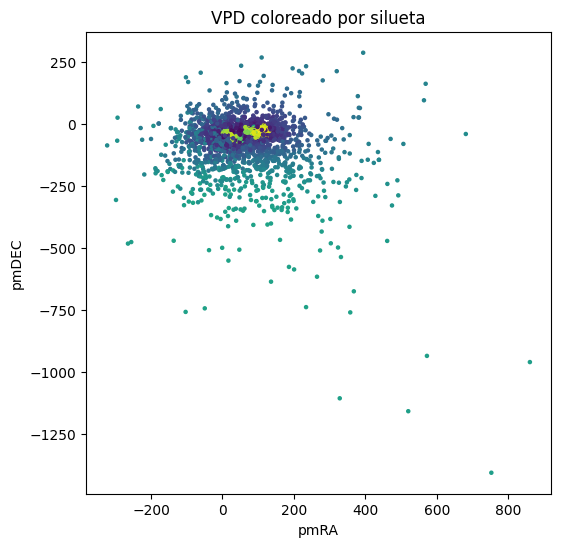

In [741]:
plt.figure(figsize=(6,6))
plt.scatter(features['pmra'], features['pmdec'], c=sil, cmap='viridis', s=5)
plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.title("VPD coloreado por silueta")
plt.colorbar(sc,label="Silhouette score")
plt.show()

Ahora trabajemos con COMA

In [742]:
df["dist_pc"] = 1000 / df["parallax"]
df86 = df[(df["dist_pc"] > 66) & (df["dist_pc"] < 106)]
df86 = df86[(df86["ra"] > 170) & (df86["ra"] < 200)]
df86 = df86[(df86["dec"] > 10) & (df86["dec"] < 40)]
print(len(df86["ra"]))
df86 = df86[(df86["parallax_over_error"] <= 0.1)]
pmra86 = df86["pmra"].values
pmdec86 = df86["pmdec"].values
print(len(df86["ra"]))

3950
3874


In [743]:
clustering_on = ['pmra','pmdec','dist_pc']

data = df86[clustering_on]
features = data

data = RobustScaler().fit_transform(data)

hd = HDBSCAN(min_cluster_size=50, min_samples=10, metric='euclidean').fit(data)

from sklearn.metrics import silhouette_samples, silhouette_score

In [744]:
labels = hd.labels_
df86['label_hb'] = labels

for i in list(set(labels)):
    print('{} {}'.format(i,len(df86[(df86['label_hb'] == i)])))

unique_labels = np.unique(labels)
# mapa de colores
cmap = plt.cm.get_cmap('tab10', len(unique_labels))
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

0 161
1 299
-1 3414


In [745]:
cluster_sizes = df86[df86['label_hb'] != -1]['label_hb'].value_counts()
main_cluster = 0
pmra_c = df86[df86['label_hb']==main_cluster]['pmra']
pmdec_c = df86[df86['label_hb']==main_cluster]['pmdec']
pmra_center = pmra_c.mean()
pmdec_center = pmdec_c.mean()
print(len(pmra_c))

161


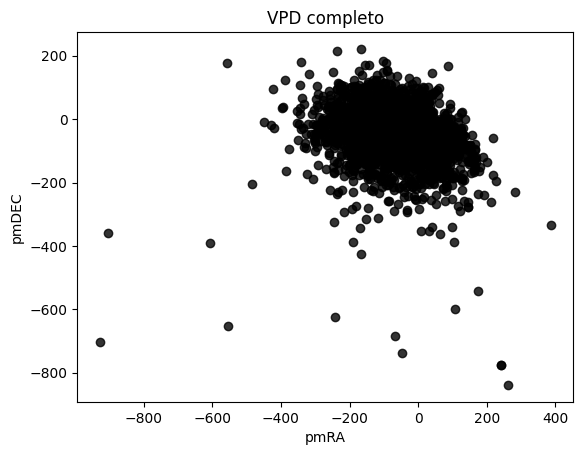

In [746]:
plt.scatter(df86['pmra'], df86['pmdec'], c='k', alpha=0.8)
plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.title("VPD completo")
plt.show()

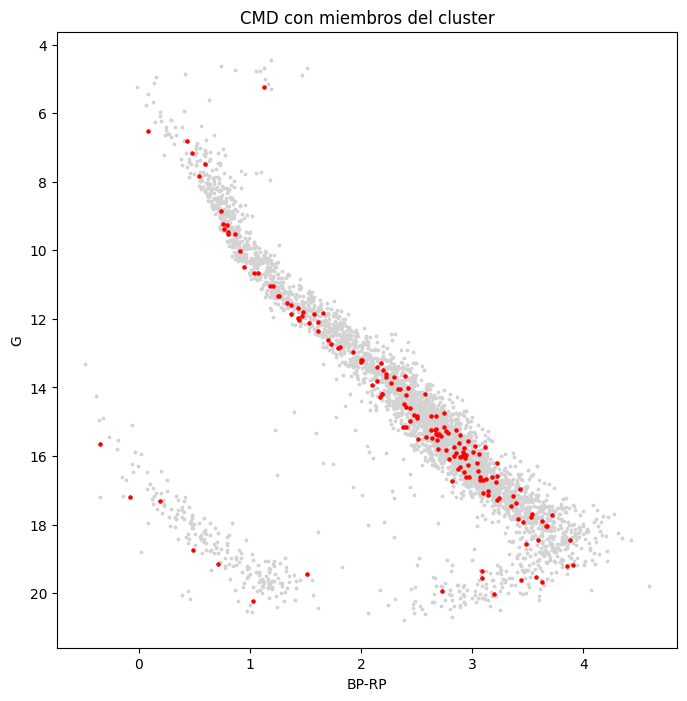

In [747]:
plt.figure(figsize=(8,8))
members = df86[df86['label_hb']==main_cluster]
plt.scatter(df86['bp_rp'],df86['phot_g_mean_mag'],c='lightgray',s=3)
plt.scatter(members['bp_rp'],members['phot_g_mean_mag'],c='red',s=5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP")
plt.ylabel("G")
plt.title("CMD con miembros del cluster")
plt.show()

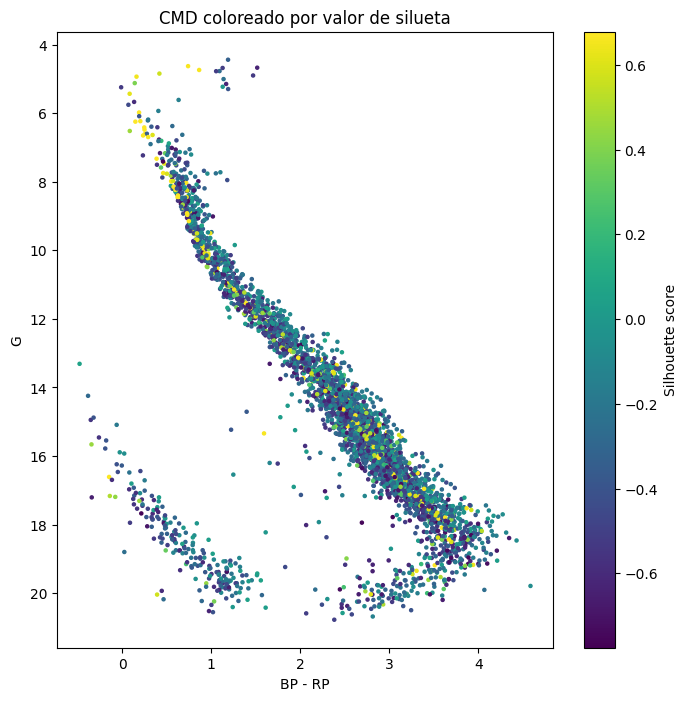

In [748]:
x = silhouette_samples(data, labels)
sil = x
df86['silhouette'] = sil
plt.figure(figsize=(8,8))
sc = plt.scatter(df86['bp_rp'],df86['phot_g_mean_mag'],c=df86['silhouette'],cmap='viridis',s=5)
plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("CMD coloreado por valor de silueta")
plt.colorbar(sc,label="Silhouette score")
plt.show()

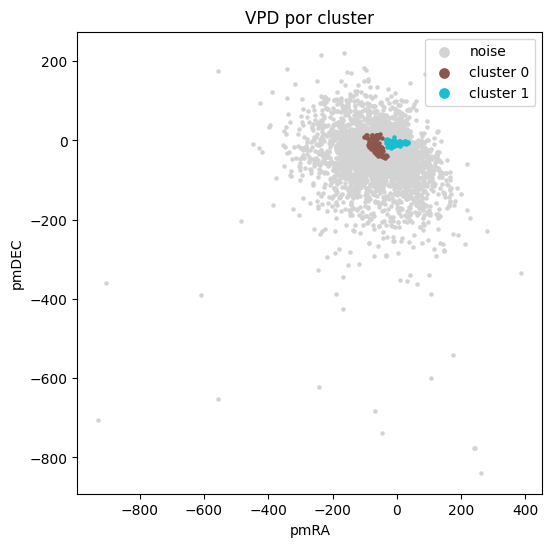

In [749]:
plt.figure(figsize=(6,6))
for lab in unique_labels:
    cond = df86['label_hb'] == lab
    if lab == -1:
        color = 'lightgray'
        label = 'noise'
    else:
        color = color_map[lab]
        label = f'cluster {lab}'
    plt.scatter(df86['pmra'][cond],df86['pmdec'][cond],s=5,color=color,label=label)
plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.title("VPD por cluster")
plt.legend(markerscale=3)
plt.show()

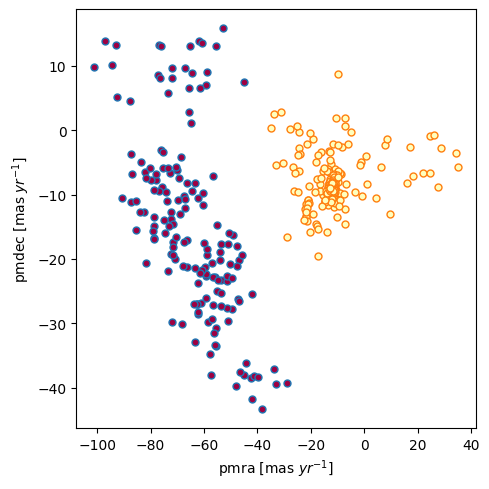

In [750]:
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (df86['label_hb'] == i)
        plt.plot(df86['pmra'][condition],df86['pmdec'][condition],markerfacecolor=tuple(j),marker='o',linestyle='None',markersize=5,alpha=1)
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.show()

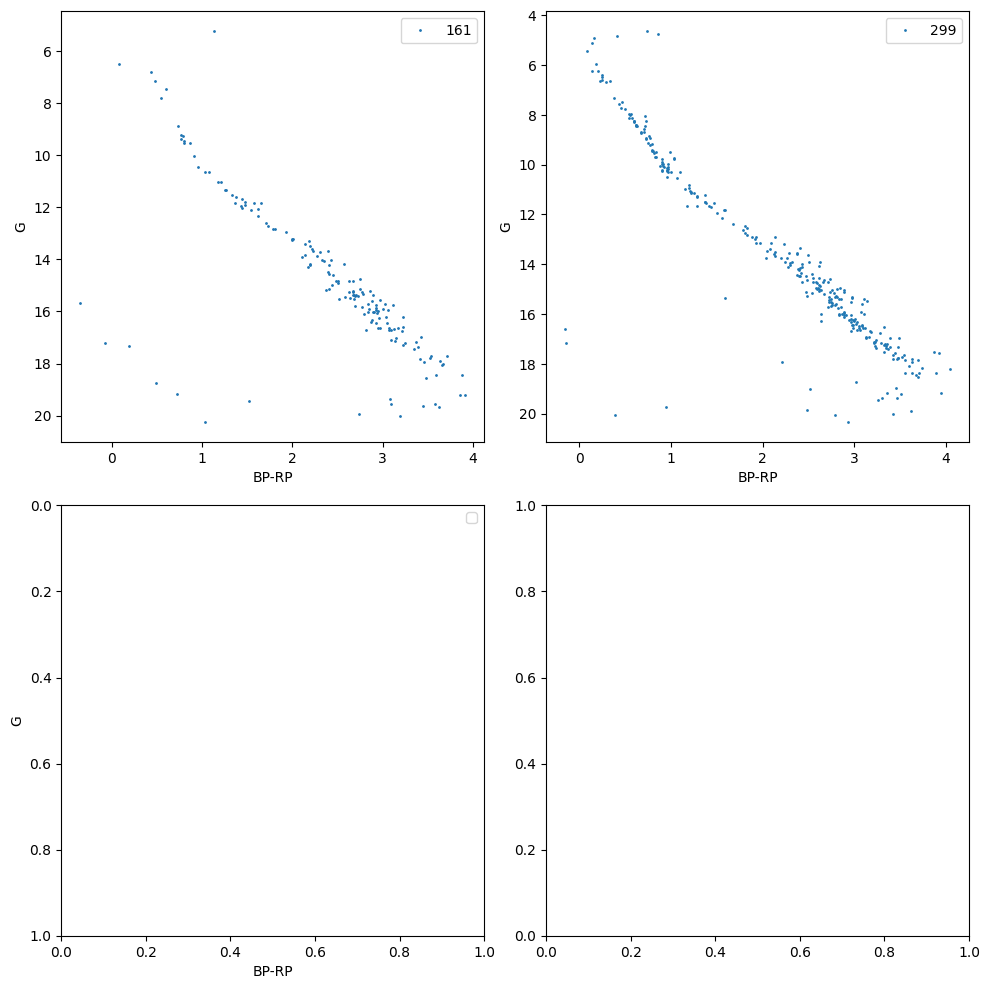

In [751]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))
for i, j, ax in zip(list(unique_labels), colors, axes.flat):
    if i != -1:
        condition = (df86['label_hb'] == i)
        ax.plot(df86['phot_bp_mean_mag'][condition] - df86['phot_rp_mean_mag'][condition],df86['phot_g_mean_mag'][condition],markerfacecolor=tuple(j),marker='o',linestyle='None',markersize=1,label=f'{len(df86[condition])}')
    ax.set_xlabel("BP-RP")
    ax.set_ylabel("G")
    ax.invert_yaxis()
    ax.legend()
fig.tight_layout()
plt.show()

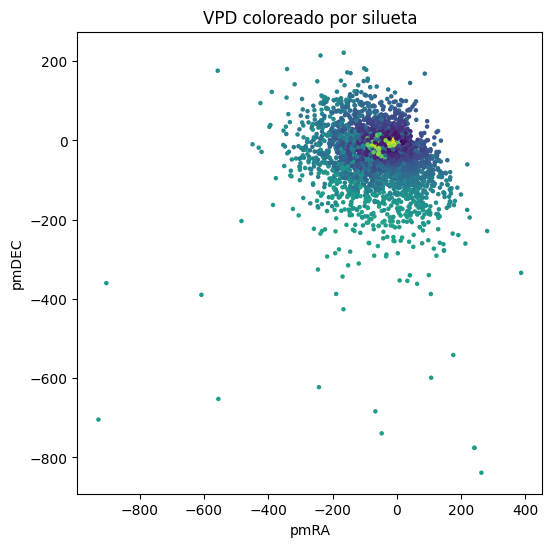

In [752]:
plt.figure(figsize=(6,6))
plt.scatter(df86['pmra'], df86['pmdec'], c=df86['silhouette'], cmap='viridis', s=5)
plt.xlabel("pmRA")
plt.ylabel("pmDEC")
plt.title("VPD coloreado por silueta")
plt.colorbar(sc, label="Silhouette score")
plt.show()

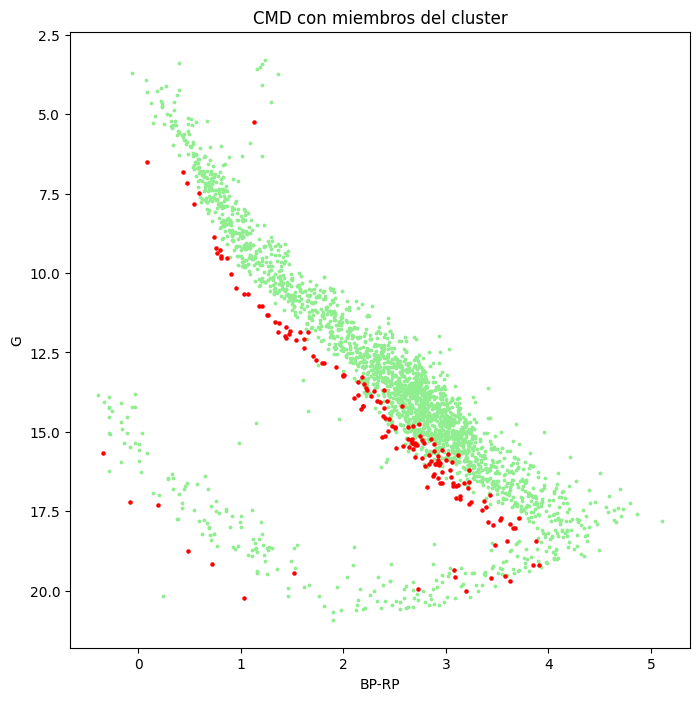

In [753]:
plt.figure(figsize=(8,8))
members = df86[df86['label_hb']==main_cluster]
plt.scatter(df46['bp_rp'],df46['phot_g_mean_mag'],c='lightgreen',s=3)
plt.scatter(members['bp_rp'],members['phot_g_mean_mag'],c='red',s=5)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP")
plt.ylabel("G")
plt.title("CMD con miembros del cluster")
plt.show()

In [754]:
print(len(df['pmra']), len(df46['pmra']), len(df86['pmra'])) 
df_clean = df.drop(df46.index.union(df86.index))
print(len(set(df_clean.index).intersection(set(df46.index))))
print(len(set(df_clean.index).intersection(set(df86.index))))
len(df_clean['pmra']), len(df['pmra']) - len(df46['pmra']) -len(df86['pmra'])

497992 2367 3874
0
0


(491751, 491751)

Ya está hecho lo chiquito, empezemos a partir el cielo en RA y DEC, de -90 a 90


In [758]:
print(df_clean["ra"].min(), df_clean["ra"].max())
print(df_clean["dec"].min(), df_clean["dec"].max())
lendec = np.abs(df_clean["dec"].min()) + np.abs(df_clean["dec"].max())
lenra = np.abs(df_clean["ra"].min()) + np.abs(df_clean["ra"].max())
df_clean = df_clean[(df_clean["parallax_over_error"] < 0.1)]
print(lendec/64, lenra/64)

0.0025649825635751 359.99992632546446
-89.86093232198749 89.63759587281338
2.804664503043764 5.625038926687938


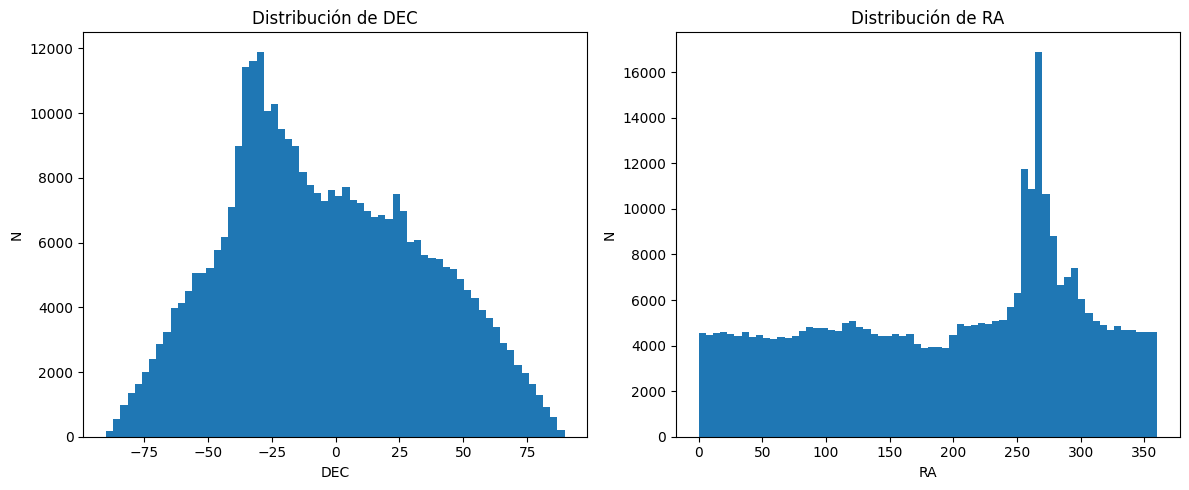

In [759]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histograma de DEC
axes[0].hist(df_clean["dec"], bins=64)
axes[0].set_xlabel("DEC")
axes[0].set_ylabel("N")
axes[0].set_title("Distribución de DEC")

# Histograma de RA
axes[1].hist(df_clean["ra"], bins=64)
axes[1].set_xlabel("RA")
axes[1].set_ylabel("N")
axes[1].set_title("Distribución de RA")

plt.tight_layout()
plt.show()

In [760]:
# número de divisiones
n_bins = 8

# bins en RA y DEC
df_clean["ra_bin"] = pd.cut(df_clean["ra"], bins=n_bins, labels=False)
df_clean["dec_bin"] = pd.cut(df_clean["dec"], bins=n_bins, labels=False)

# construir label único 1–64
df_clean["region_label"] = df_clean["dec_bin"]*n_bins + df_clean["ra_bin"] + 1

df_clean.to_csv("df_clean_Bruno.csv", index=False)